In [1]:
import sys
import os
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Add src to path
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), "src"))

import config
from src.data_loader import build_panel, split_panel, prepare_tensors
from train_test_val.managed_portfolios import compute_managed_portfolios_from_tensors
from train_test_val.models import build_model
from train_test_val.train import AssetPricingDataset, ensemble_predict_month

# ==========================================
# CONFIGURATION:
# ==========================================
MODEL_DIR = "outputs/models"  # Change to "outputs/models_with_ETFs" to use ETF models
FACTORS_DIR = "data/factors"  # Change to "data/factors_with_ETFs" to use ETF models  # Change to "outputs/models_with_ETFs" to use ETF models
 List of (architecture, K) pairs to process
# ==========================================
configs = [
    ("CA0", 5),
    ("CA1", 5)
    ("CA2", 5),
]

print(f"Will process {len(configs)} configurations: {configs}")  

<>:23: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
<>:23: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
c:\Users\johng\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
C:\Users\johng\AppData\Local\Temp\ipykernel_18576\418575118.py:23: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  ("CA1", 5)


TypeError: 'tuple' object is not callable

In [ ]:
# Load processed data
print("Loading processed panel...")
df = pd.read_parquet(config.PROCESSED_DIR + "panel_processed.parquet")
char_cols = [c for c in df.columns if c not in ("permno", "date", "ret")]
print(f"Loaded {len(df):,} stock-months, {len(char_cols)} characteristics")

# Split into train/val/test (same as run.py)
train_df, val_df, test_df = split_panel(df, train_end=200512, val_end=201012)
# uncomment if you want to use the test set for exporting
'''
# Prepare tensors
ret_train, chr_train, msk_train, dates_train = prepare_tensors(train_df, char_cols)
ret_val, chr_val, msk_val, dates_val = prepare_tensors(val_df, char_cols)
ret_test, chr_test, msk_test, dates_test = prepare_tensors(test_df, char_cols)

# Managed portfolios
mp_train = compute_managed_portfolios_from_tensors(ret_train, chr_train, msk_train)
mp_val = compute_managed_portfolios_from_tensors(ret_val, chr_val, msk_val)
mp_test = compute_managed_portfolios_from_tensors(ret_test, chr_test, msk_test)

MP = mp_train.shape[1]
P = len(char_cols)

# Build test dataset
test_data = AssetPricingDataset(ret_test, chr_test, mp_test, msk_test)
print(f"Test dataset: {test_data.n_obs:,} observations, {test_data.T} months")
'''

ret_full, chr_full, msk_full, dates_full = prepare_tensors(df, char_cols)

# Compute Managed portfolios for the full dataset
mp_full = compute_managed_portfolios_from_tensors(ret_full, chr_full, msk_full)

MP = mp_full.shape[1]
P = len(char_cols)

# Build the full dataset object
full_data = AssetPricingDataset(ret_full, chr_full, mp_full, msk_full)
print(f"Full dataset: {full_data.n_obs:,} observations, {full_data.T} months")

Loading processed panel...
Loaded 4,221,335 stock-months, 56 characteristics
  Train: 2,640,591 obs (197201-200512)
  Val:   403,373 obs (200601-201012)
  Test:  1,177,371 obs (201101-202312)
Full dataset: 4,221,335 observations, 624 months


In [ ]:
def load_models(architecture, K, P, MP, n_seeds=10, model_dir=MODEL_DIR):
    """Load saved ensemble models."""
    models = []
    for seed in range(n_seeds):
        model = build_model(architecture, P, MP, K)
        path = Path(model_dir) / f"{architecture}_K{K}_seed{seed}.pt"
        if path.exists():
            model.load_state_dict(torch.load(path, map_location=config.DEVICE))
            model.to(config.DEVICE)
            model.eval()
            models.append(model)
        else:
            print(f"  Seed {seed} not found")

    return models

In [ ]:
def extract_factor_series(test_data, models, dates_test, K):
    """Extract factor time series from models."""
    factor_series = []
    dates_list = []

    for t in range(test_data.T):
        chars_t, returns_t, mp_t = test_data.get_month_data(t)
        if len(returns_t) == 0:
            continue
        
        # Get ensemble-averaged factors
        _, _, f = ensemble_predict_month(models, chars_t, mp_t)
        factor_series.append(f.cpu().numpy())
        dates_list.append(dates_test[t])

    factor_series = np.array(factor_series)  # Shape: (T, K)
    dates_list = np.array(dates_list)

    # Create DataFrame
    factor_df = pd.DataFrame(factor_series, columns=[f"Factor_{k+1}" for k in range(K)])
    factor_df['date'] = dates_list
    factor_df = factor_df.set_index('date')

    return factor_df


Processing CA0 with K=5
  Loading models...
  Loaded 10 models
  Extracting factors...
  Extracted 624 months, 5 factors
  Saved to data/factors/CA0_K5_factors.csv


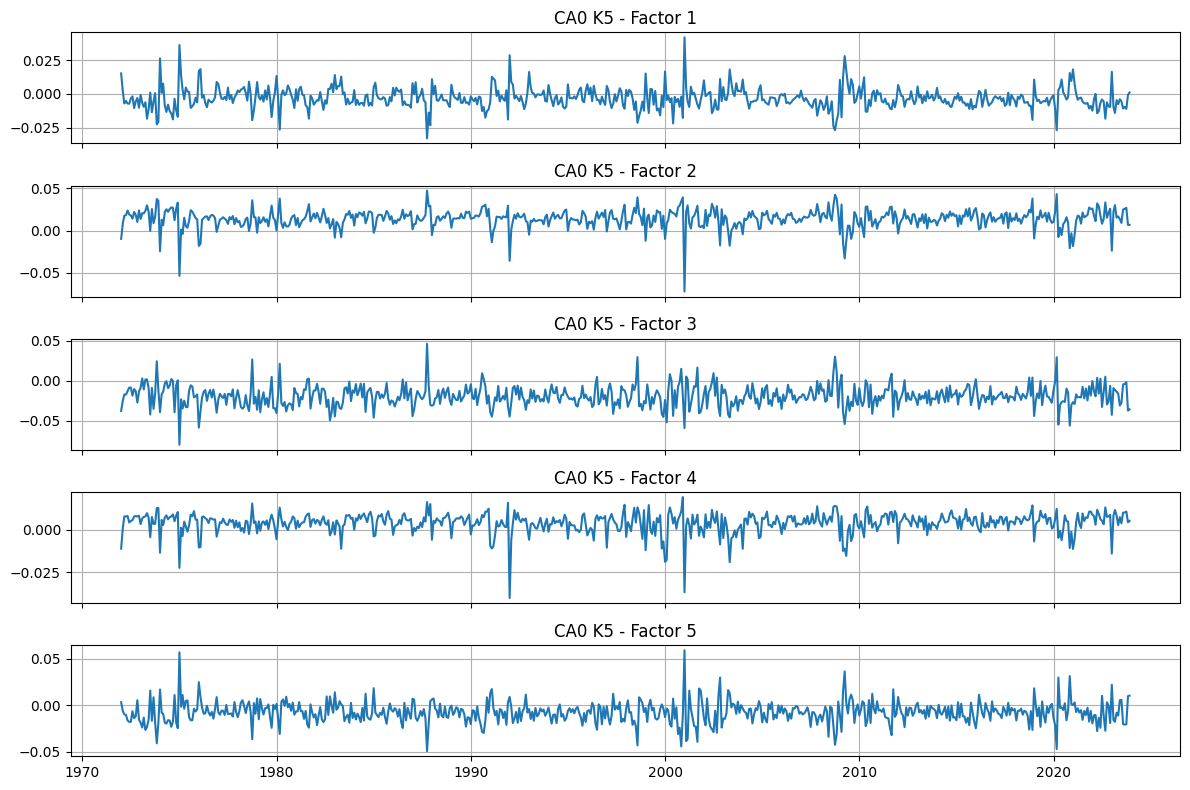


Processing CA2 with K=5
  Loading models...
  Loaded 10 models
  Extracting factors...
  Extracted 624 months, 5 factors
  Saved to data/factors/CA2_K5_factors.csv


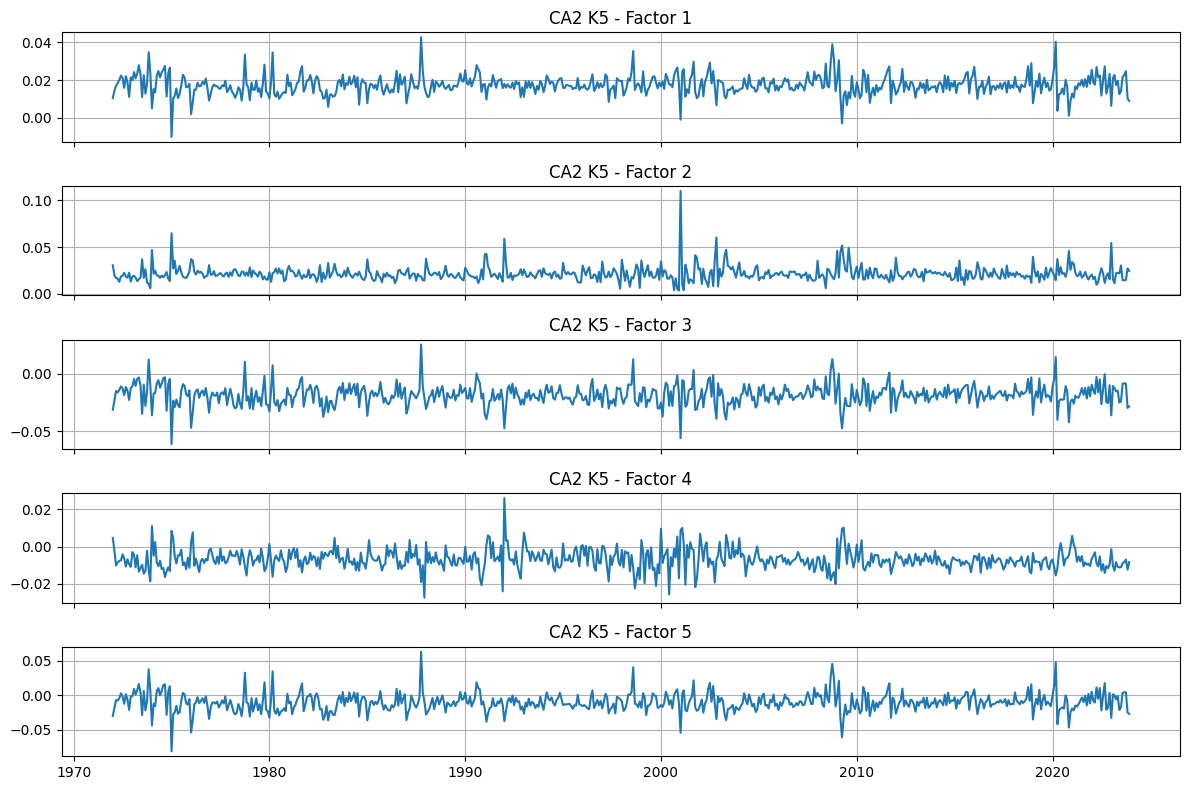


All configurations processed!


In [ ]:
def save_and_plot_factors(factor_df, architecture, K, factors_dir=FACTORS_DIR):
    """Save factor time series and plot."""
    # Create factors folder
        os.makedirs(factors_dir, exist_ok=True)
    output_path = f"{factors_dir}/{architecture}_K{K}_factors.csv"
    factor_df.to_csv(output_path)
    print(f"  Saved to {output_path}")

    # Convert dates to datetime for better plotting
    factor_df_plot = factor_df.copy()
    factor_df_plot.index = pd.to_datetime(factor_df_plot.index.astype(str), format='%Y%m')

    # Plot factors
    fig, axes = plt.subplots(K, 1, figsize=(12, 8), sharex=True)
    if K == 1:
        axes = [axes]  # Handle case where K=1
    
    for k in range(K):
        axes[k].plot(factor_df_plot.index, factor_df_plot[f"Factor_{k+1}"])
        axes[k].set_title(f"{architecture} K{K} - Factor {k+1}")
        axes[k].grid(True)

    plt.tight_layout()
    plt.savefig(config.FIGURE_DIR + f"{architecture}_K{K}_factors.png")
    plt.show()


# ==========================================
# PROCESS ALL CONFIGURATIONS
# ==========================================
for architecture, K in configs:
    print(f"\n{'='*60}")
    print(f"Processing {architecture} with K={K}")
    print(f"{'='*60}")
    
    # Load models
    print(f"  Loading models...")
    models = load_models(architecture, K, P, MP)
    if len(models) == 0:
        print(f"  ERROR: No models found for {architecture} K={K}, skipping...")
        continue
    print(f"  Loaded {len(models)} models")
    
    # Extract factors
    print(f"  Extracting factors...")
    # factor_df = extract_factor_series(test_data, models, dates_test, K)
    factor_df = extract_factor_series(full_data, models, dates_full, K)
    print(f"  Extracted {factor_df.shape[0]} months, {K} factors")
    
    # Save and plot
    save_and_plot_factors(factor_df, architecture, K)

print(f"\n{'='*60}")
print("All configurations processed!")
print(f"{'='*60}")